In [1]:
import numpy as np
import pandas as pd
#import seaborn as sns
import plotly.express as px
from matplotlib import pyplot as plt
from sklearn.model_selection import cross_val_score

from sklearn import metrics
from collections import Counter

In [2]:
df_feat = pd.read_csv(r'E:\Users\Avishka\JobData\MyProjects\ml-model\data\Processed-Telco-Customer-Churn.csv')


C:\Users\Avishka Koswaththa\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Fitting 3 folds for each of 50 candidates, totalling 150 fits
Best parameters: {'colsample_bytree': 0.6708442717628196, 'gamma': 4.702292921764571, 'learning_rate': 0.2961785731007762, 'max_depth': 7, 'min_child_weight': 6, 'n_estimators': 198, 'subsample': 0.8990875095589655}
Optimal threshold by F1-score: 0.5199999999999998
--- Training Set ---
ROC AUC: 0.9116129225145266
              precision    recall  f1-score   support

           0       0.94      0.81      0.87      4139
           1       0.61      0.85      0.71      1495

    accuracy                           0.82      5634
   macro avg       0.78      0.83      0.79      5634
weighted avg       0.85      0.82      0.83      5634

Confusion Matrix:
 [[3332  807]
 [ 217 1278]]


--- Test Set ---
ROC AUC: 0.8345281459092201
              precision    recall  f1-score   support

           0       0.89      0.76      0.82      1035
           1       0.52      0.74      0.62       374

    accuracy                           

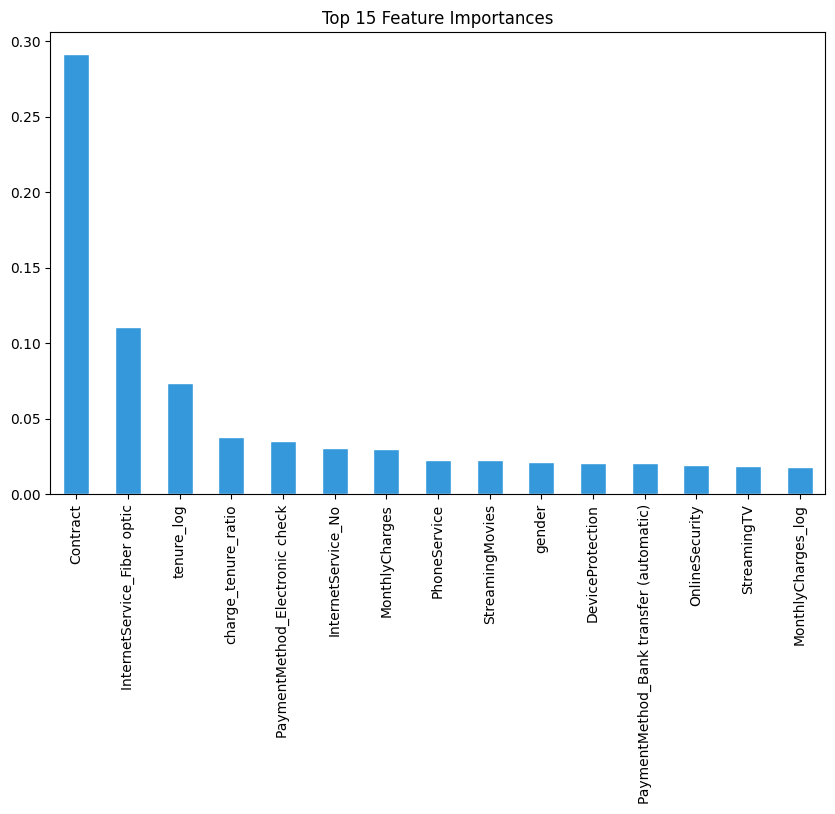

In [3]:
# ------------------------------
# 1️⃣ Imports
# ------------------------------
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, f1_score
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
from scipy.stats import randint, uniform

# ------------------------------
# 2️⃣ Features & Target
# ------------------------------
target_col = 'Churn'
feature_cols = [c for c in df_feat.columns if c != target_col]

X = df_feat[feature_cols].values
y = df_feat[target_col].values

# ------------------------------
# 3️⃣ Train-Test Split
# ------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ------------------------------
# 4️⃣ XGBoost Hyperparameter Search
# ------------------------------
xgb_clf = xgb.XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss',  # required to suppress warning
    scale_pos_weight=len(y_train[y_train==0])/len(y_train[y_train==1])  # imbalance handling
)

param_dist = {
    'n_estimators': randint(100, 500),
    'max_depth': randint(3, 10),
    'learning_rate': uniform(0.01, 0.3),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'gamma': uniform(0, 5),
    'min_child_weight': randint(1, 10)
}

random_search = RandomizedSearchCV(
    xgb_clf,
    param_distributions=param_dist,
    n_iter=50,
    scoring='f1',
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)
best_xgb = random_search.best_estimator_
print("Best parameters:", random_search.best_params_)

# ------------------------------
# 5️⃣ Threshold Tuning
# ------------------------------
y_proba_test = best_xgb.predict_proba(X_test)[:,1]

best_threshold = 0.5
best_f1 = 0
thresholds = np.arange(0.1, 0.9, 0.01)
for t in thresholds:
    y_pred = (y_proba_test >= t).astype(int)
    f1 = f1_score(y_test, y_pred)
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print("Optimal threshold by F1-score:", best_threshold)
y_pred_test = (y_proba_test >= best_threshold).astype(int)

# ------------------------------
# 6️⃣ Evaluation Function
# ------------------------------
def evaluate(model, X, y, y_pred=None, dataset_name="Dataset"):
    if y_pred is None:
        y_pred = model.predict(X)
    y_proba = model.predict_proba(X)[:,1]
    print(f"--- {dataset_name} ---")
    print("ROC AUC:", roc_auc_score(y, y_proba))
    print(classification_report(y, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y, y_pred))
    print("\n")

evaluate(best_xgb, X_train, y_train, 
         y_pred=(best_xgb.predict_proba(X_train)[:,1]>=best_threshold).astype(int),
         dataset_name="Training Set")
evaluate(best_xgb, X_test, y_test, y_pred=y_pred_test, dataset_name="Test Set")

# ------------------------------
# 7️⃣ Feature Importances
# ------------------------------
feat_importance = pd.Series(best_xgb.feature_importances_, index=feature_cols).sort_values(ascending=False)
plt.figure(figsize=(10,6))
feat_importance[:15].plot(kind='bar', color='#3498db', edgecolor='white')
plt.title("Top 15 Feature Importances")
plt.show()

# ------------------------------
# 8️⃣ SHAP Analysis
# ------------------------------
# explainer = shap.TreeExplainer(best_xgb)
# shap_values = explainer.shap_values(X_test)

# # Global summary plot
# shap.summary_plot(shap_values, X_test, feature_names=feature_cols)

# # Optional: force plot for first customer
# shap.force_plot(explainer.expected_value, shap_values[0,:], X_test[0,:], feature_names=feature_cols)

In [4]:
import joblib
import os

# ------------------------------
# 9️⃣ Save XGBoost model + threshold
# ------------------------------
model_dir = r"E:\Users\Avishka\JobData\MyProjects\ml-model\models"
os.makedirs(model_dir, exist_ok=True)

# Save both model and threshold as a dictionary
model_filename = os.path.join(model_dir, "xgb_churn_model.pkl")
joblib.dump({
    "model": best_xgb,
    "threshold": best_threshold,
    "feature_cols": feature_cols  # optional but recommended
}, model_filename)

print(f"Model and threshold saved to {model_filename}")

Model and threshold saved to E:\Users\Avishka\JobData\MyProjects\ml-model\models\xgb_churn_model.pkl


In [ ]:
# Load model + threshold
saved = joblib.load(model_filename)
loaded_model = saved["model"]
threshold = saved["threshold"]
features = saved["feature_cols"]

# Prepare your test set
X_test_loaded = df_feat[features].values  # make sure columns match
y_proba_test = loaded_model.predict_proba(X_test_loaded)[:,1]
y_pred_test = (y_proba_test >= threshold).astype(int)